In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno




In [ ]:


df_train = pd.read_csv("train.csv")
df_test  = pd.read_csv("test.csv")

print(df_train.shape)   # (891, 12)
df_train.head()



(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
nulos = df_train.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0])

Cabin       687
Age         177
Embarked      2
dtype: int64


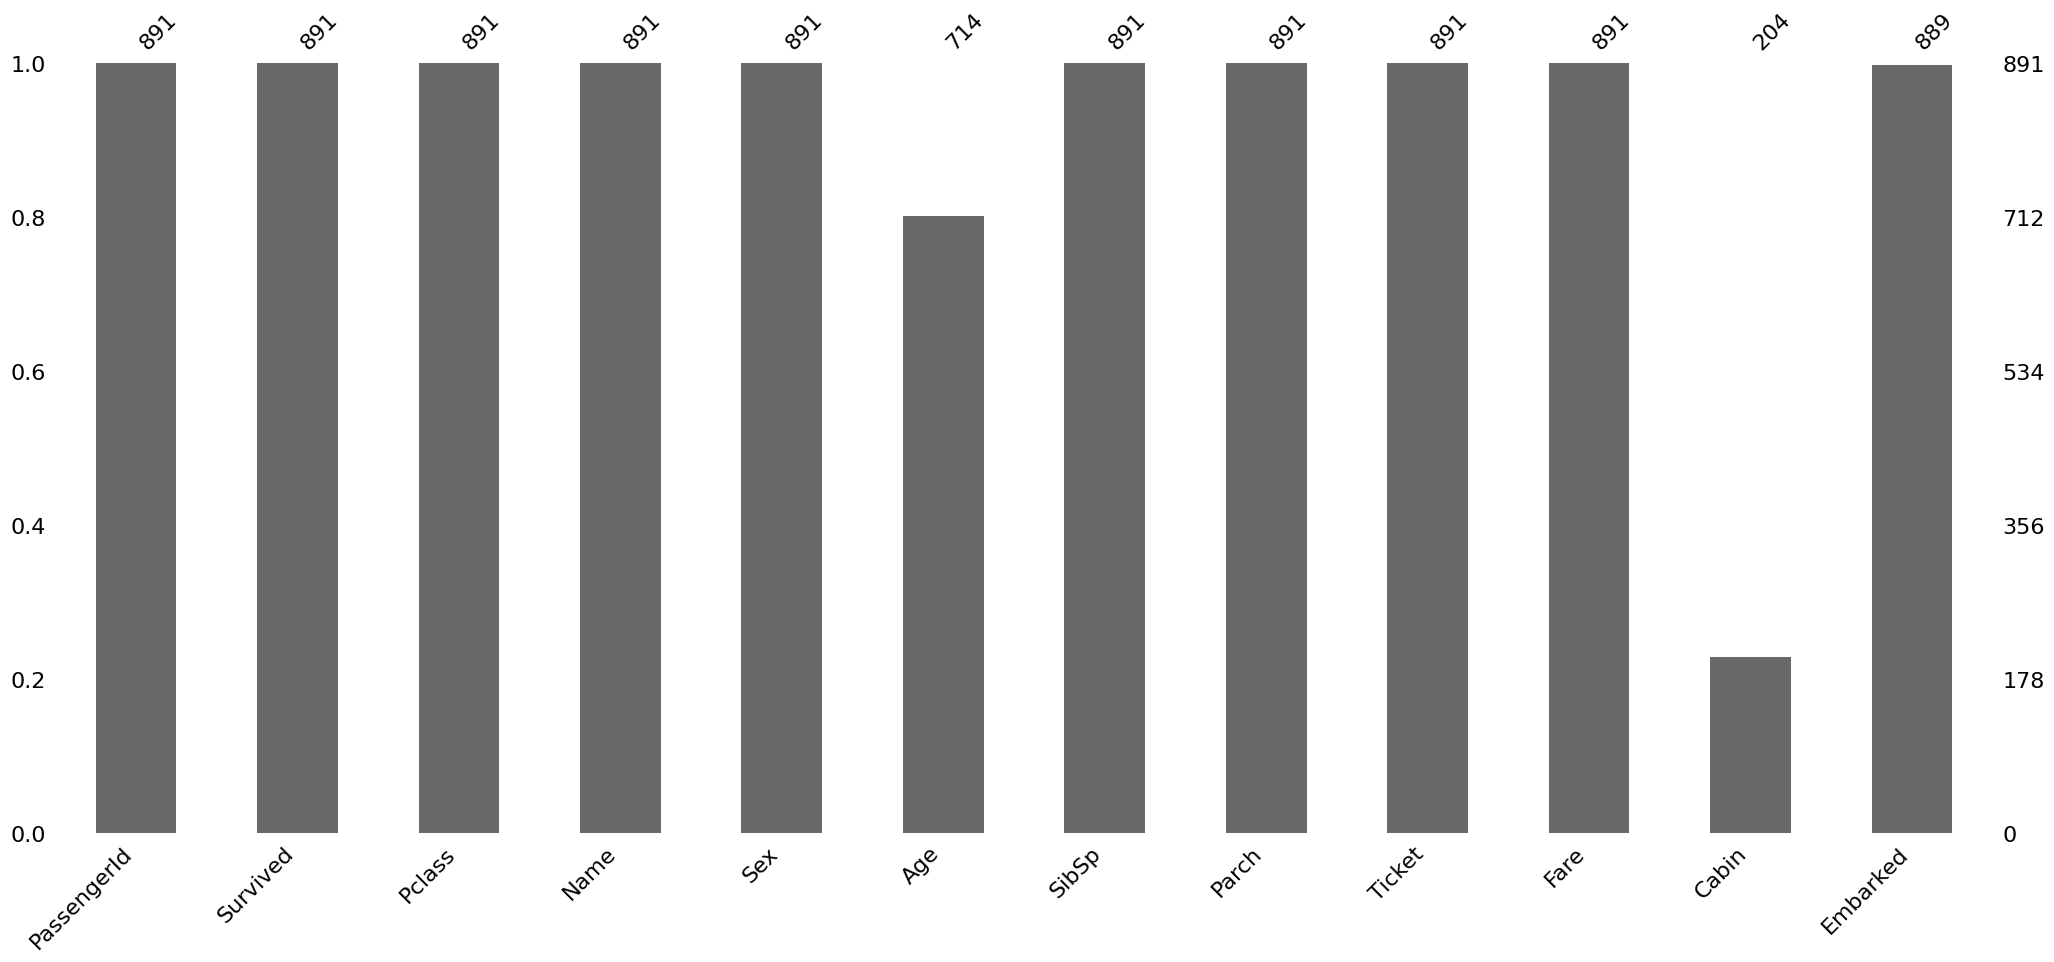

In [ ]:
msno.bar(df_train)
plt.show()

In [ ]:
# Age: preenche com a mediana
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Embarked: preenche com a moda
df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

# Cabin: descarta só se ainda existir
if "Cabin" in df_train.columns:
    df_train.drop(columns=["Cabin"], inplace=True)

# Confirma
print(df_train.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_9304\255519919.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(["Não sobreviveu", "Sobreviveu"])


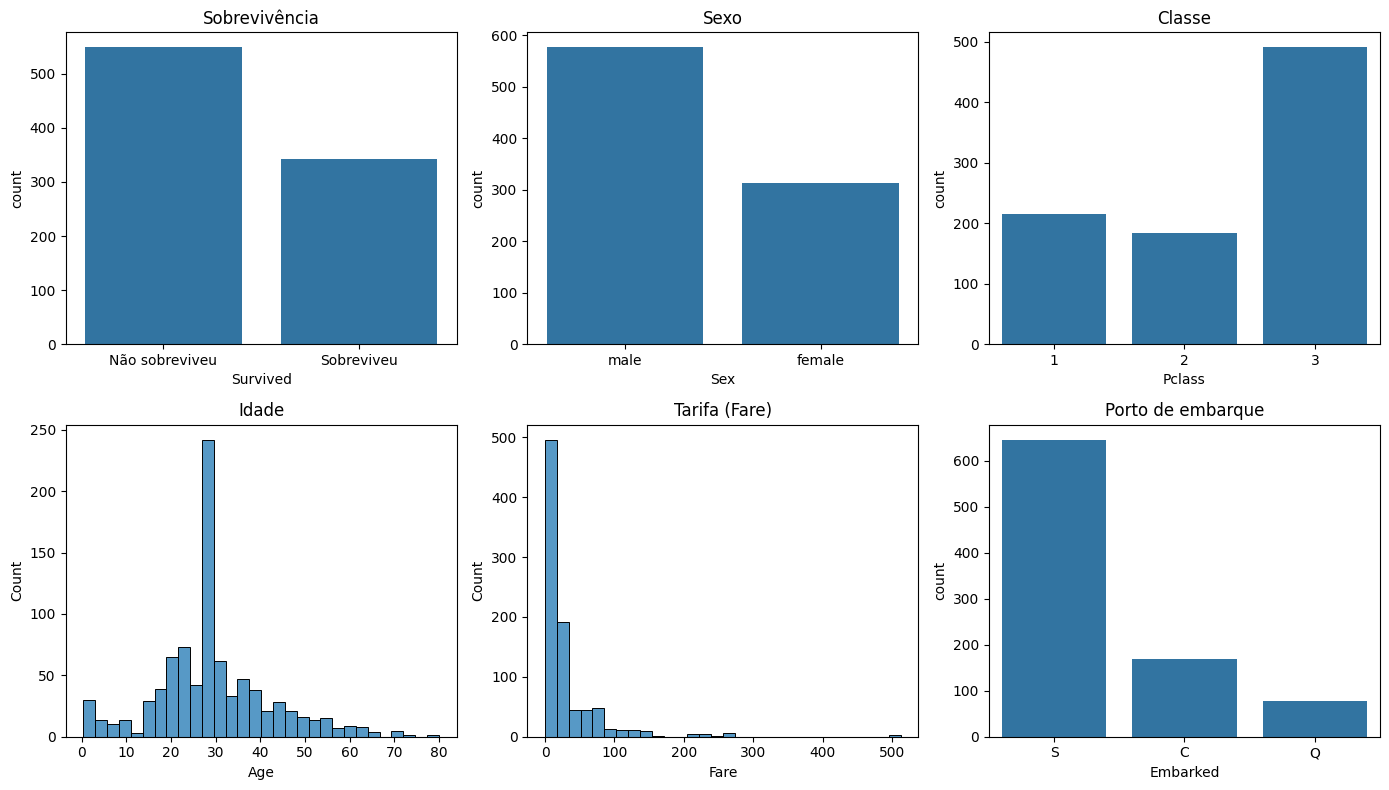

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Sobrevivência
sns.countplot(x="Survived", data=df_train, ax=axes[0,0])
axes[0,0].set_title("Sobrevivência")
axes[0,0].set_xticklabels(["Não sobreviveu", "Sobreviveu"])

# Sexo
sns.countplot(x="Sex", data=df_train, ax=axes[0,1])
axes[0,1].set_title("Sexo")

# Classe
sns.countplot(x="Pclass", data=df_train, ax=axes[0,2])
axes[0,2].set_title("Classe")

# Idade
sns.histplot(df_train["Age"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Idade")

# Tarifa
sns.histplot(df_train["Fare"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Tarifa (Fare)")

# Porto de embarque
sns.countplot(x="Embarked", data=df_train, ax=axes[1,2])
axes[1,2].set_title("Porto de embarque")

plt.tight_layout()
plt.show()

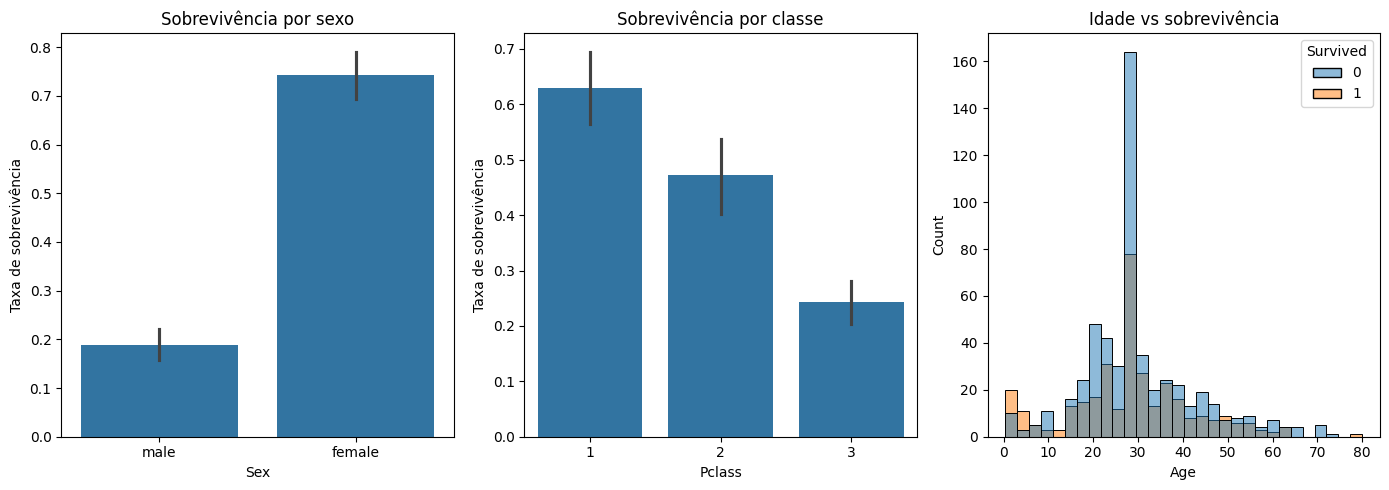

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Sobrevivência por sexo
sns.barplot(x="Sex", y="Survived", data=df_train, ax=axes[0])
axes[0].set_title("Sobrevivência por sexo")
axes[0].set_ylabel("Taxa de sobrevivência")

# Sobrevivência por classe
sns.barplot(x="Pclass", y="Survived", data=df_train, ax=axes[1])
axes[1].set_title("Sobrevivência por classe")
axes[1].set_ylabel("Taxa de sobrevivência")

# Sobrevivência por idade
sns.histplot(data=df_train, x="Age", hue="Survived", bins=30, ax=axes[2])
axes[2].set_title("Idade vs sobrevivência")

plt.tight_layout()
plt.show()


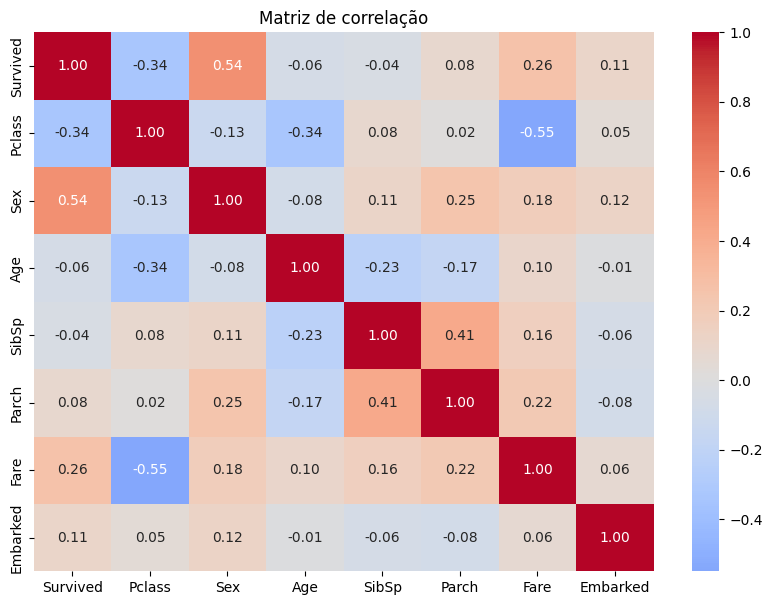

In [ ]:
# Codifica variáveis categóricas
df_corr = df_train.copy()
df_corr["Sex"] = df_corr["Sex"].map({"male": 0, "female": 1})
df_corr["Embarked"] = df_corr["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Remove colunas que não fazem sentido correlacionar
df_corr.drop(columns=["Name", "Ticket", "PassengerId"], inplace=True)

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação")
plt.show()

In [ ]:
# FamilySize: tamanho total da família a bordo
df_train["FamilySize"] = df_train["SibSp"] + df_train["Parch"] + 1

# IsAlone: viajava sozinho?
df_train["IsAlone"] = (df_train["FamilySize"] == 1).astype(int)

# Title: título extraído do nome
df_train["Title"] = df_train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df_train["Title"] = df_train["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare"
)
df_train["Title"] = df_train["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# Visualiza
print(df_train["Title"].value_counts())
print("\nSobrevivência por tamanho de família:")
print(df_train.groupby("FamilySize")["Survived"].mean().round(2))

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Sobrevivência por tamanho de família:
FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64


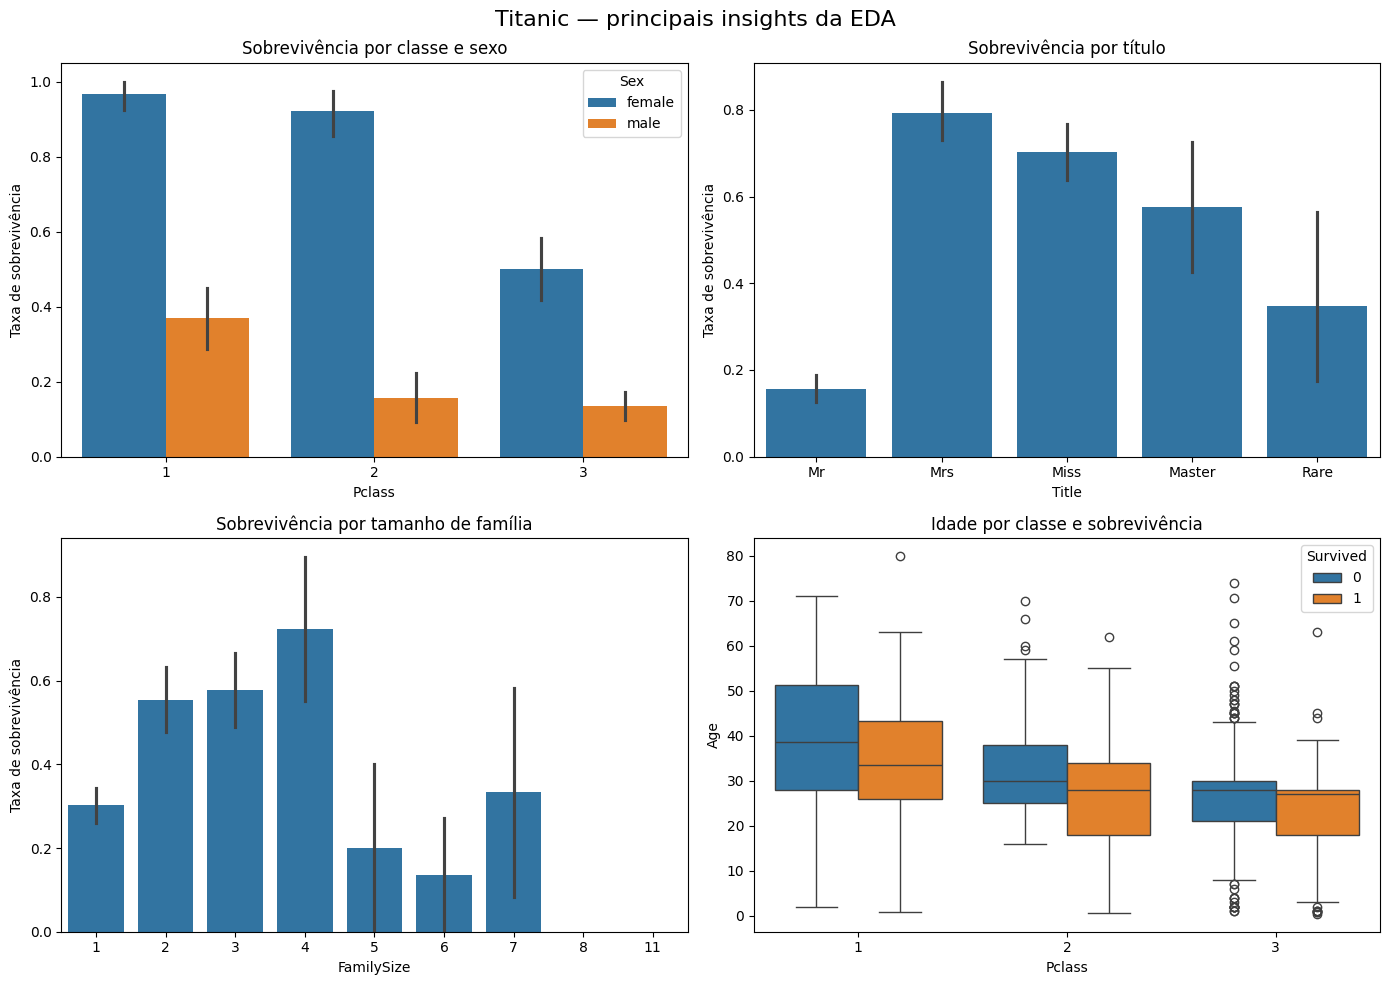

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic — principais insights da EDA", fontsize=16)

# Sobrevivência por sexo e classe
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df_train, ax=axes[0,0])
axes[0,0].set_title("Sobrevivência por classe e sexo")
axes[0,0].set_ylabel("Taxa de sobrevivência")

# Sobrevivência por título
sns.barplot(x="Title", y="Survived", data=df_train, ax=axes[0,1])
axes[0,1].set_title("Sobrevivência por título")
axes[0,1].set_ylabel("Taxa de sobrevivência")

# Sobrevivência por tamanho de família
sns.barplot(x="FamilySize", y="Survived", data=df_train, ax=axes[1,0])
axes[1,0].set_title("Sobrevivência por tamanho de família")
axes[1,0].set_ylabel("Taxa de sobrevivência")

# Idade por classe e sobrevivência
sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df_train, ax=axes[1,1])
axes[1,1].set_title("Idade por classe e sobrevivência")

plt.tight_layout()
plt.show()